The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


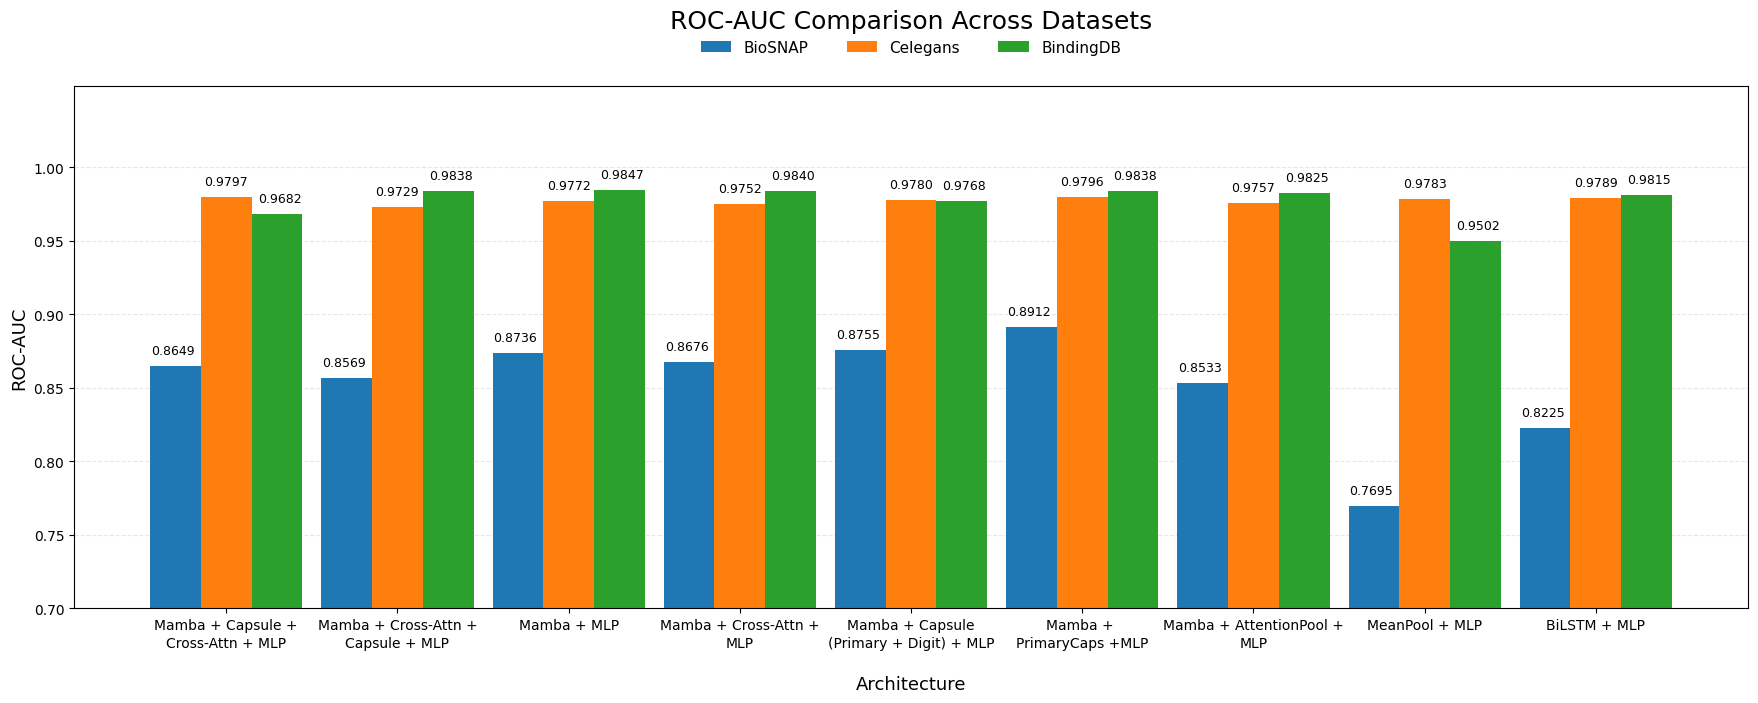

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DATA
# ============================================================

architectures = [
    "Mamba + Capsule +\nCross-Attn + MLP",
    "Mamba + Cross-Attn +\nCapsule + MLP",
    "Mamba + MLP",
    "Mamba + Cross-Attn +\nMLP",
    "Mamba + Capsule\n(Primary + Digit) + MLP",
    "Mamba + \nPrimaryCaps +MLP",
    "Mamba + AttentionPool +\nMLP",
    "MeanPool + MLP",
    "BiLSTM + MLP",
]

biosnap = np.array([
    0.8649, 0.8569, 0.8736, 0.8676, 0.8755,
    0.8912, 0.8533, 0.7695, 0.8225
])

celegans = np.array([
    0.9797, 0.9729, 0.9772, 0.9752, 0.9780,
    0.9796, 0.9757, 0.9783, 0.9789
])

bindingdb = np.array([
    0.9682, 0.9838, 0.9847, 0.9840, 0.9768,
    0.9838, 0.9825, 0.9502, 0.9815
])

# ============================================================
# BAR POSITIONING
# ============================================================

# Width of EACH individual bar
bar_width = 0.4

# Distance between the CENTERS of architecture groups
group_spacing = 1.35

# Architecture group centers
x = np.arange(len(architectures)) * group_spacing

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(18, 9))

# Three bars TOUCH each other within every architecture
bars1 = ax.bar(
    x - bar_width,
    biosnap,
    width=bar_width,
    label="BioSNAP"
)

bars2 = ax.bar(
    x,
    celegans,
    width=bar_width,
    label="Celegans"
)

bars3 = ax.bar(
    x + bar_width,
    bindingdb,
    width=bar_width,
    label="BindingDB"
)

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "ROC-AUC Comparison Across Datasets",
    fontsize=18,
    pad=42
)

# ============================================================
# AXES
# ============================================================

ax.set_ylabel(
    "ROC-AUC",
    fontsize=13
)

ax.set_xlabel(
    "Architecture",
    fontsize=13,
    labelpad=18
)

ax.set_xticks(x)

ax.set_xticklabels(
    architectures,
    fontsize=10,
    ha="center",
    linespacing=1.35
)

# ============================================================
# Y-AXIS
# ============================================================

ax.set_ylim(0.70, 1.055)

ax.set_yticks(
    np.arange(0.70, 1.01, 0.05)
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

ax.set_axisbelow(True)

# ============================================================
# LEGEND
# ============================================================

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.115),
    ncol=3,
    frameon=False,
    fontsize=11,
    columnspacing=2.5
)


# ============================================================
# VALUE LABELS — CLEAN SPACING
# ============================================================

def add_value_labels(bars, offset):

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2 + offset,
            value + 0.006,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


add_value_labels(bars1, -0.02)
add_value_labels(bars2,  0.00)
add_value_labels(bars3,  0.02)

# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.055,
    right=0.985,
    bottom=0.20,
    top=0.78
)

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "ROC_AUC_Comparison_600dpi.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "ROC_AUC_Comparison_600dpi.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()